# Iter-5 $0 re-analysis — synthetic-Allen small-bite + one-thesis contribution table

This notebook is a **runnable, annotated** version of `eval.py`, a **zero-spend** (numpy-only,
deterministic, no LLM calls) re-analysis that extends a validated iter-4 re-analysis for the
paper *"No Derivation, No Relation: A Closure Certificate"*.

It produces three deliverables for the paper, in four steps:

- **STEP 0 — sanity gate.** Re-check the iter-4 headline numbers against the published values and
  record any mismatch (there should be **0**).
- **STEP 1 (MINOR #5a) — synthetic Allen positive control.** Re-run the consistent-by-construction
  Allen qualitative-constraint-network control at reader-recall 0.95, then a **paired bootstrap**
  (B resamples) to put CIs on two effects: the *small* cross-path **coverage** bite (+0.024, CI
  includes 0) vs the *large* **selective-accuracy** gain (+0.259, CI excludes 0). Net message:
  the win is **precision of committed answers**, not coverage expansion.
- **STEP 2 (MINOR #5b) — inverted-U on the realized-coverage axis.** Recover, per (recall, K)
  redundancy bin, the realized Mode-A coverage `= benefit + cost_silent_wrong = 1 − abstain − collapse`
  with Wilson/Newcombe CIs; peak K* rises 2→16 with recall while silent-wrong rises 0.006→0.146.
- **STEP 3 (MAJOR #3) — one-thesis contribution table** with evidence tags in **columns**.

**Inputs** are bundled into `mini_demo_data.json` (a curated subset of several dependency JSON
files), including the source of the two modules STEP 1 re-runs (`engine.py`, `synth_allen.py`).
The whole analysis is `$0` and runs in seconds.


## Setup — install dependencies

`eval.py` needs only **numpy** plus **loguru** (logging). We add **matplotlib** for the demo
visualization. Following the Colab rules: install `loguru` everywhere; install the core
packages (`numpy`, `matplotlib`) only when **not** on Colab (Colab already ships them, and
re-installing corrupts the pre-loaded C extensions).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru -- NOT pre-installed on Colab -> install everywhere
_pip('loguru==0.7.2')

# numpy, matplotlib -- pre-installed on Colab -> install locally only, at Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports and logging

Copied from the top of `eval.py` (same imports + loguru sink setup), plus `matplotlib`
for the final visualization cell.

In [2]:
from __future__ import annotations

import gc
import json
import math
import resource
import sys
from pathlib import Path

import numpy as np
from loguru import logger

import matplotlib.pyplot as plt  # added for the demo visualization cell

# ----------------------------------------------------------------------------- logging
Path("logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add("logs/run.log", rotation="30 MB", level="DEBUG")

2

## Data loading

The original `eval.py` read four dependency JSON files from disk and imported two Python
modules from a dependency workspace. For this demo, everything needed is curated into a single
`mini_demo_data.json`, loaded from GitHub (with a local fallback so the notebook also runs
offline).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-5/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

### Load the bundle and reconstruct the analysis inputs

`data` stands in for the dependency files the original script read separately:

| original `eval.py` variable | bundled key |
|---|---|
| `iter4` (iter-4 eval_out.json) | `data["iter4_eval"]` |
| `published_cell` (synth-Allen recall_95 cell) | `data["published_cell"]` |
| `channel` (inverted-U H4 channel) | `data["channel"]` |
| `clutrr_src` (CLUTRR certificate) | `data["clutrr_src"]` |

STEP 1 re-runs the synthetic Allen control by *importing* `engine` + `synth_allen`, so we
materialize their bundled source to a local folder and put it on `sys.path` (the original
inserted the dependency workspace path here).

In [4]:
data = load_data()

# Reconstruct the analysis inputs (these replace the four on-disk dependency JSON files).
iter4 = data["iter4_eval"]
published_cell = data["published_cell"]
channel = data["channel"]
clutrr_src = data["clutrr_src"]

# Materialize the two modules STEP 1 imports + re-runs, then put them on sys.path.
SYNTH_DIR = Path("synth_modules"); SYNTH_DIR.mkdir(exist_ok=True)
(SYNTH_DIR / "engine.py").write_text(data["engine_py"])
(SYNTH_DIR / "synth_allen.py").write_text(data["synth_allen_py"])

logger.info(f"loaded demo bundle keys: {list(data.keys())}")
logger.info(f"iter4 carried datasets: {[(d['dataset'], len(d['examples'])) for d in iter4['datasets']]}")

22:47:08|INFO   |loaded demo bundle keys: ['iter4_eval', 'published_cell', 'channel', 'clutrr_src', 'engine_py', 'synth_allen_py']


22:47:08|INFO   |iter4 carried datasets: [('clutrr_templated_kinship', 5), ('temporal_point_algebra_natural_text', 5)]


## Config — tunable parameters

All scale knobs live here. They start small for a fast demo; the **original** values are noted
in comments.

- `N_NET` — number of synthetic Allen networks for the positive control. **500 reproduces the
  published `recall_95` cell exactly**; smaller values make the reproduction check fall back to
  analytic (Wilson/Newcombe) CIs (still valid, just not an exact reproduction).
- `B_BOOT` — paired-bootstrap resamples for the CIs.

The original code also caps process address space at 8 GB; in a notebook kernel that can clash
with already-mapped memory, so we apply it defensively inside a `try`.

In [5]:
# ============================ TUNABLE CONFIG ============================
SEED = 20260617           # global deterministic seed (ORIGINAL: 20260617)
ALPHA = 0.05              # CI level
Z = 1.959963984540054     # norm.ppf(0.975)

N_NET = 500               # synthetic Allen networks.    ORIGINAL: 500  (500 == exact reproduction)
B_BOOT = 10000            # paired bootstrap resamples.   ORIGINAL: 10000

# Memory cap (original eval.py: 8 GB address-space cap). Apply defensively in a notebook.
_RAM_BUDGET = 8 * 1024 ** 3
try:
    resource.setrlimit(resource.RLIMIT_AS, (_RAM_BUDGET, _RAM_BUDGET))
    logger.info(f"RLIMIT_AS capped at {_RAM_BUDGET/1024**3:.0f} GB")
except (ValueError, OSError) as e:
    logger.warning(f"skipping RLIMIT_AS cap in notebook context: {e}")

22:47:08|INFO   |RLIMIT_AS capped at 8 GB


## Bootstrap / CI helpers

Copied verbatim from `eval.py`. `clustered_bootstrap_ci` and `holm_bonferroni` are carried for
traceability (they produced the temporal numbers reused later); `wilson_ci` and
`newcombe_diff_ci` are the single/paired-proportion intervals used in STEP 1's fallback and
throughout STEP 2.

In [6]:
def clustered_bootstrap_ci(doc_to_vals, B=None, seed=None, alpha=None):
    B = B_BOOT if B is None else B
    seed = SEED if seed is None else seed
    alpha = ALPHA if alpha is None else alpha
    docs = [d for d, v in doc_to_vals.items() if v]
    if len(docs) < 2:
        allv = [x for v in doc_to_vals.values() for x in v]
        m = float(np.mean(allv)) if allv else float("nan")
        return [m, m]
    rng = np.random.default_rng(seed)
    arrs = {d: np.array(doc_to_vals[d], dtype=float) for d in docs}
    nd = len(docs)
    means = []
    for _ in range(B):
        pick = rng.integers(0, nd, nd)
        vals = np.concatenate([arrs[docs[i]] for i in pick])
        means.append(vals.mean())
    lo, hi = np.quantile(means, [alpha / 2, 1 - alpha / 2])
    return [float(lo), float(hi)]


def holm_bonferroni(pvals: dict, alpha=ALPHA):
    """Return {name: {p, adjusted_significant}} via Holm step-down."""
    items = sorted(pvals.items(), key=lambda kv: kv[1])
    m = len(items)
    out = {}
    rejected_all_below = True
    for rank, (name, p) in enumerate(items):
        thresh = alpha / (m - rank)
        sig = (p <= thresh) and rejected_all_below
        if not sig:
            rejected_all_below = False
        out[name] = {"p": float(p), "holm_threshold": float(thresh),
                     "adjusted_significant": bool(sig)}
    return out


def wilson_ci(x: int, n: int, z: float = Z):
    """Wilson score interval for a single proportion x/n."""
    if n == 0:
        return [float("nan"), float("nan")]
    p = x / n
    denom = 1.0 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half = (z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))) / denom
    return [float(center - half), float(center + half)]


def newcombe_diff_ci(x1: int, n1: int, x2: int, n2: int, z: float = Z):
    """Newcombe (method 10) score interval for the difference of two INDEPENDENT
    proportions p1 - p2 (each (recall,K) cell is an independent 600-network draw)."""
    l1, u1 = wilson_ci(x1, n1, z)
    l2, u2 = wilson_ci(x2, n2, z)
    p1, p2 = x1 / n1, x2 / n2
    lo = (p1 - p2) - math.sqrt((p1 - l1) ** 2 + (u2 - p2) ** 2)
    hi = (p1 - p2) + math.sqrt((u1 - p1) ** 2 + (p2 - l2) ** 2)
    return [float(lo), float(hi)]

## STEP 0 — sanity gate (reproduce iter-4 headline numbers)

Compare each reproduced point estimate against the validated iter-4 `eval_out.json`. Mismatches
are listed, never silently overwritten. Expected: **0 mismatches**.

In [7]:
def step0_sanity(iter4: dict) -> dict:
    logger.info("STEP 0 -- reproducing iter-4 headline numbers (sanity gate)")
    ma = iter4["metrics_agg"]
    md = iter4["metadata"]
    mismatches = []

    def check(name, got, expected, tol=1e-4):
        ok = (got is not None) and (abs(float(got) - expected) <= tol)
        if not ok:
            mismatches.append({"name": name, "got": got, "expected": expected})
            logger.error(f"  MISMATCH {name}: got={got} expected={expected}")
        else:
            logger.info(f"  OK {name} = {got}")
        return ok

    # Headline numbers that feed the spine / footnotes.
    check("clutrr_modeA_selacc", ma.get("clutrr_modeA_selacc"), 0.885714)
    check("clutrr_modeA_vs_pot_gap", ma.get("clutrr_modeA_vs_pot_gap"), 0.428571)
    pot_ci = md["clutrr_matched_coverage_gaps"]["gaps"]["pot"]["new_ci95"]
    check("clutrr_vs_pot_ci_lo", pot_ci[0], 0.298589, tol=1e-3)
    check("clutrr_vs_pot_ci_hi", pot_ci[1], 0.563015, tol=1e-3)
    check("temporal_vs_pot_ci_lo", ma.get("temporal_modeA_vs_pot_new_ci_lo"), -0.088276)
    check("temporal_vs_pot_ci_hi", ma.get("temporal_modeA_vs_pot_new_ci_hi"), 0.139723)
    check("temporal_vs_pot_boot_p", ma.get("temporal_modeA_vs_pot_new_boot_p"), 0.3322)
    check("temporal_confident_wrong_frac", ma.get("temporal_confident_wrong_frac"), 0.424779)
    cw = md["temporal_confident_wrong_block"]
    check("temporal_confident_wrong_n", cw["n_confident_wrong"], 48, tol=0.5)
    check("temporal_confident_wrong_denom", cw["denom_answered"], 113, tol=0.5)

    logger.info(f"STEP 0 done: {len(mismatches)} mismatch(es)")
    return {"n_mismatches": len(mismatches), "mismatches": mismatches,
            "note": "every reproduced point estimate compared vs the iter-4 validated "
                    "eval_out.json; mismatches (if any) listed here, never silently overwritten."}


repro = step0_sanity(iter4)
print("\nSTEP 0 reproduction mismatches:", repro["n_mismatches"])

22:47:08|INFO   |STEP 0 -- reproducing iter-4 headline numbers (sanity gate)


22:47:08|INFO   |  OK clutrr_modeA_selacc = 0.885714


22:47:08|INFO   |  OK clutrr_modeA_vs_pot_gap = 0.428571


22:47:08|INFO   |  OK clutrr_vs_pot_ci_lo = 0.298589


22:47:08|INFO   |  OK clutrr_vs_pot_ci_hi = 0.563015


...

22:47:08|INFO   |  OK temporal_confident_wrong_frac = 0.424779


22:47:08|INFO   |  OK temporal_confident_wrong_n = 48


22:47:08|INFO   |  OK temporal_confident_wrong_denom = 113


22:47:08|INFO   |STEP 0 done: 0 mismatch(es)



STEP 0 reproduction mismatches: 0


## STEP 1 (MINOR #5a) — synthetic Allen positive control + paired bootstrap

`_rows_via_synth_allen` re-runs `synth_allen.run_control` draw-for-draw (so the aggregate
reproduces the published `recall_95` cell) **and** captures a parallel verbose view (the true
relation + each method's resolved set) for the worked examples. The three methods compared:

- **intersection** — full path-consistency (PC-2) closure across all cross-paths, then read the
  query edge.
- **best_single** — the single min-cardinality 2-step composition path.
- **naive** — one single pass of length-2 intersections at the query edge (no fixpoint).

`step1_synth_allen` aggregates coverage / selective-accuracy per method, decomposes where the
precision advantage comes from, runs a **paired** bootstrap over the `N_NET` networks for the
coverage and selective-accuracy gain CIs, and (if `N_NET=500`) checks exact reproduction of the
published cell — otherwise it falls back to analytic Wilson/Newcombe CIs.

> The only change from the original is the `sys.path` insert (now the local `SYNTH_DIR`) and
> `n_net = N_NET` (was hard-coded 500).

In [8]:
def _rows_via_synth_allen(n_net: int, r: float, seed: int):
    """Re-run the $0 synthetic Allen positive control EXACTLY as the iter-4 experiment did
    (SA.run_control body), but ALSO expose the per-network rows. Mirrors
    synth_allen.run_control(n_net, r, seed) draw-for-draw so the aggregate reproduces the
    published recall_95 cell. Also returns a parallel VERBOSE view (true relation + resolved
    set per method) for worked examples, computed from a fresh, identically-seeded RNG."""
    sys.path.insert(0, str(SYNTH_DIR))   # (original: dependency workspace path)
    import engine  # noqa: F401  (imported by synth_allen)
    import synth_allen as SA

    AL = SA.AL

    # --- authoritative loop: identical to SA.run_control, capturing rows -------------
    rng = np.random.default_rng(seed)
    full_rows = [SA.run_one(6, r, rng) for _ in range(n_net)]
    rows = {m: [fr[m] for fr in full_rows] for m in ("intersection", "best_single", "naive")}

    # --- verbose loop: identical draw sequence, capturing true_q + resolved sets ------
    def run_one_verbose(n_events, rr, rg):
        intervals = SA.gen_network(n_events, rg)
        nodes = list(range(n_events))
        s, t = 0, 1
        vias = nodes[2:]
        true_q = SA._atomic(intervals, s, t)
        qcn = engine.QCN(AL, nodes)
        reads, confs = {}, {}
        induced = [(s, w) for w in vias] + [(w, t) for w in vias]
        for i in range(len(vias)):
            for j in range(i + 1, len(vias)):
                induced.append((vias[i], vias[j]))
        for (a, b) in induced:
            tr = SA._atomic(intervals, a, b)
            rd = SA.simulate_read(tr, rr, rg)
            reads[(a, b)] = rd
            confs[(a, b)] = float(min(1.0, max(0.0, rg.normal(0.7, 0.15))))
            qcn.set_edge(qcn.index[a], qcn.index[b], rd)
        qi, qj = qcn.index[s], qcn.index[t]
        naive_set = engine.naive_single_pass(qcn, qi, qj)
        per_path = [AL.compose(reads[(s, w)], reads[(w, t)]) for w in vias]
        best = min(per_path, key=len) if per_path else AL.universe
        ok, _ = engine.pc2_full(qcn)
        inter = AL.empty if not ok else qcn.get(qi, qj)

        def render(R):
            if not R:
                return "ABSTAIN(collapse-empty)"
            if len(R) == 1:
                return str(next(iter(R)))
            return "ABSTAIN(disjunction:" + "|".join(sorted(str(x) for x in R)) + ")"
        return {"true_q": str(true_q), "intersection_set": sorted(str(x) for x in inter),
                "best_single_set": sorted(str(x) for x in best),
                "naive_set": sorted(str(x) for x in naive_set),
                "intersection_pred": render(inter), "best_single_pred": render(best),
                "naive_pred": render(naive_set),
                "bite": len(best) - len(inter)}

    rng2 = np.random.default_rng(seed)
    verbose = [run_one_verbose(6, r, rng2) for _ in range(n_net)]
    return rows, full_rows, verbose


def _to_arrays(rows):
    """answered (0/1) and correct (0/1, 0 where not answered) per method as numpy arrays."""
    out = {}
    for m, recs in rows.items():
        ans = np.array([1.0 if x["answered"] else 0.0 for x in recs])
        cor = np.array([float(x["correct"]) if (x["answered"] and x["correct"] is not None)
                        else 0.0 for x in recs])
        out[m] = (ans, cor)
    return out

In [9]:
def step1_synth_allen(published_cell: dict) -> dict:
    logger.info("STEP 1 (MINOR #5a) -- synthetic Allen control small-bite, paired bootstrap")
    n_net, r = N_NET, 0.95                 # (original: n_net hard-coded 500)
    seed_cell = SEED + int(r * 100)  # 20260617 + 95 = 20260712
    logger.info(f"  reproducing recall_95 cell: SA.run_control(n_net={n_net}, r={r}, seed={seed_cell})")
    rows, full_rows, verbose = _rows_via_synth_allen(n_net, r, seed_cell)

    arr = _to_arrays(rows)
    agg = {}
    for m, (ans, cor) in arr.items():
        cov = float(ans.mean())
        sel = float(cor[ans > 0].sum() / ans.sum()) if ans.sum() > 0 else float("nan")
        agg[m] = {"coverage": cov, "selective_acc": sel,
                  "n_answered": int(ans.sum()), "n_correct": int(cor.sum())}
        logger.info(f"    {m}: coverage={cov:.4f} selective_acc={sel:.4f} "
                    f"(answered={int(ans.sum())} correct={int(cor.sum())})")

    # ----- precision decomposition (where intersection's precision advantage comes from) -----
    ai, ci = arr["intersection"]
    ab, cb = arr["best_single"]
    both_m = (ai > 0) & (ab > 0)
    inter_only_m = (ai > 0) & (ab == 0)
    best_only_m = (ab > 0) & (ai == 0)
    precision_decomposition = {
        "n_both_resolve": int(both_m.sum()),
        "n_intersection_only": int(inter_only_m.sum()),
        "n_best_single_only": int(best_only_m.sum()),
        "both_resolve_intersection_correct": int(ci[both_m].sum()),
        "both_resolve_best_single_correct": int(cb[both_m].sum()),
        "intersection_only_correct": int(ci[inter_only_m].sum()),
        "intersection_only_acc": float(ci[inter_only_m].sum() / max(1, inter_only_m.sum())),
        "best_single_only_correct_kept": int(cb[best_only_m].sum()),
        "best_single_only_WRONG_avoided_by_collapse": int(best_only_m.sum() - cb[best_only_m].sum()),
        "note": ("Intersection's precision (0.976) beats best-single (0.717) through TWO channels, "
                 "NOT by re-scoring shared queries: (1) on the queries BOTH resolve, intersection "
                 "narrows to the SAME singleton best-single found (perfect agreement); (2) on "
                 "queries only intersection resolves (cross-path bite), it is ~96% correct; (3) on "
                 "queries only best-single resolves, intersection COLLAPSES (abstains) -- avoiding "
                 "best-single's wrong commitments instead of guessing. The coverage gain is small "
                 "(+2.4%) but the avoided-wrong-commitments + high-precision extra coverage drive "
                 "the precision advantage."),
    }
    logger.info(f"  precision decomposition: both={precision_decomposition['n_both_resolve']} "
                f"inter_only={precision_decomposition['n_intersection_only']} "
                f"(acc {precision_decomposition['intersection_only_acc']:.2f}) "
                f"best_only={precision_decomposition['n_best_single_only']} "
                f"(wrong avoided by collapse="
                f"{precision_decomposition['best_single_only_WRONG_avoided_by_collapse']})")

    # ----- BLOCKING reproduction check vs published recall_95 cell -----
    pub = published_cell["per_method"]
    repro_ok = True
    repro_detail = {}
    for m in ("intersection", "best_single", "naive"):
        dcov = abs(agg[m]["coverage"] - pub[m]["coverage"])
        dsel = abs(agg[m]["selective_acc"] - pub[m]["selective_acc"])
        repro_detail[m] = {"d_coverage": dcov, "d_selective_acc": dsel}
        if dcov > 1e-6 or dsel > 1e-6:
            repro_ok = False
    dgain = abs((agg["intersection"]["coverage"] - agg["best_single"]["coverage"])
                - published_cell["coverage_gain_intersection_vs_best"])
    if dgain > 1e-6:
        repro_ok = False
    logger.info(f"  reproduction check: {'PASS' if repro_ok else 'FAIL'} "
                f"(max coverage_gain diff {dgain:.2e})")

    cov_gain_point = agg["intersection"]["coverage"] - agg["best_single"]["coverage"]
    sel_gain_point = agg["intersection"]["selective_acc"] - agg["best_single"]["selective_acc"]

    if repro_ok:
        # ---------- PAIRED bootstrap over the networks (same indices for both) ----------
        rng = np.random.default_rng(SEED)
        ai, ci = arr["intersection"]
        ab, cb = arr["best_single"]
        an, cn = arr["naive"]
        both = (ai > 0) & (ab > 0)  # networks BOTH intersection and best-single resolve

        cg, sg, sg_aligned = [], [], []
        cov_b = {m: [] for m in ("intersection", "best_single", "naive")}
        sel_b = {m: [] for m in ("intersection", "best_single", "naive")}
        idx_all = rng.integers(0, n_net, size=(B_BOOT, n_net))
        for bidx in range(B_BOOT):
            idx = idx_all[bidx]
            covi = ai[idx].mean(); covb = ab[idx].mean(); covn = an[idx].mean()
            di = ai[idx].sum(); db = ab[idx].sum(); dn = an[idx].sum()
            seli = ci[idx][ai[idx] > 0].sum() / di if di > 0 else np.nan
            selb = cb[idx][ab[idx] > 0].sum() / db if db > 0 else np.nan
            seln = cn[idx][an[idx] > 0].sum() / dn if dn > 0 else np.nan
            cg.append(covi - covb)
            sg.append(seli - selb)
            cov_b["intersection"].append(covi); cov_b["best_single"].append(covb); cov_b["naive"].append(covn)
            sel_b["intersection"].append(seli); sel_b["best_single"].append(selb); sel_b["naive"].append(seln)
            # aligned: among networks BOTH resolve in this resample, fraction correct each
            bm = both[idx]
            dboth = bm.sum()
            if dboth > 0:
                ia = ci[idx][bm].sum() / dboth
                ba = cb[idx][bm].sum() / dboth
                sg_aligned.append(ia - ba)
        cg = np.array(cg); sg = np.array(sg); sg_aligned = np.array(sg_aligned)

        def pctci(a):
            a = a[~np.isnan(a)]
            return [float(np.quantile(a, ALPHA / 2)), float(np.quantile(a, 1 - ALPHA / 2))]

        per_method = {}
        for m in ("intersection", "best_single", "naive"):
            per_method[m] = {
                "coverage": agg[m]["coverage"], "coverage_ci": pctci(np.array(cov_b[m])),
                "selective_acc": agg[m]["selective_acc"], "selacc_ci": pctci(np.array(sel_b[m])),
                "n_answered": agg[m]["n_answered"], "n_correct": agg[m]["n_correct"]}

        n_both = int(both.sum())
        ia_point = float(ci[both].sum() / n_both) if n_both else float("nan")
        ba_point = float(cb[both].sum() / n_both) if n_both else float("nan")
        result = {
            "recall": r, "n_net": n_net, "seed_cell": seed_cell, "B": B_BOOT,
            "reproduction_failed": False, "analytic_ci_fallback": False,
            "per_method": per_method,
            "coverage_gain_intersection_vs_best": {
                "point": float(cov_gain_point), "ci95": pctci(cg),
                "boot_p_le_0": float(np.mean(cg <= 0))},
            "selacc_gain_intersection_vs_best": {
                "point": float(sel_gain_point), "ci95": pctci(sg),
                "boot_p_le_0": float(np.mean(sg <= 0)),
                "note": "difference of the two per-resample SELECTIVE accuracies (different "
                        "denominators by construction: intersection answers more queries)."},
            "selacc_gain_aligned_both_resolve": {
                "n_both_resolve": n_both,
                "intersection_acc": ia_point, "best_single_acc": ba_point,
                "acc_gain": (ia_point - ba_point) if n_both else float("nan"),
                "ci95": pctci(sg_aligned) if len(sg_aligned) else [float("nan"), float("nan")],
                "note": "among queries BOTH methods resolve, intersection narrows to the SAME "
                        "singleton best-single found (inter is a SUBSET of best), so the aligned "
                        "selective-accuracy gain is ~0. The precision advantage comes from (a) "
                        "extra queries intersection resolves via cross-path bite and (b) "
                        "intersection COLLAPSING (abstaining) where best-single commits a wrong "
                        "singleton -- NOT from re-scoring the shared queries."},
            "mean_bite": published_cell["mean_bite"],
            "singleton_resolved_rate": published_cell["singleton_resolved_rate"],
            "reproduction_detail": repro_detail,
            "precision_decomposition": precision_decomposition,
            "tag": "SYNTHETIC-ALLEN-CONTROL",
            "interpretation": (
                "Intersection sets are a SUBSET of best-single sets (tighter), so intersection "
                "mechanically resolves a SUPERSET of queries WHEN it does not collapse -- but the "
                "REALIZED coverage gain is only +2.4% absolute (0.250 vs 0.226), while the "
                "selective-accuracy gain is large (+25.9 pts; 0.976 vs 0.717) and intersection's "
                "precision (0.976) exceeds BOTH best_single (0.717) AND naive (0.842) even though "
                "naive answers MORE (0.316). Structurally the only resolution-axis win is a "
                "coverage superset, but its realized MAGNITUDE is tiny; the practically meaningful "
                "effect is PRECISION OF COMMITTED ANSWERS, not coverage expansion."),
        }
    else:
        logger.error("  reproduction FAILED -> analytic (Wilson/Newcombe) CI fallback")
        per_method = {}
        for m in ("intersection", "best_single", "naive"):
            na = agg[m]["n_answered"]
            per_method[m] = {
                "coverage": agg[m]["coverage"],
                "coverage_ci": wilson_ci(na, n_net),
                "selective_acc": agg[m]["selective_acc"],
                "selacc_ci": wilson_ci(agg[m]["n_correct"], na) if na else [float("nan")] * 2,
                "n_answered": na, "n_correct": agg[m]["n_correct"]}
        ni = agg["intersection"]["n_answered"]; nb = agg["best_single"]["n_answered"]
        result = {
            "recall": r, "n_net": n_net, "seed_cell": seed_cell, "B": 0,
            "reproduction_failed": True, "analytic_ci_fallback": True,
            "per_method": per_method,
            "coverage_gain_intersection_vs_best": {
                "point": float(cov_gain_point),
                "ci95": newcombe_diff_ci(ni, n_net, nb, n_net),
                "boot_p_le_0": float("nan")},
            "selacc_gain_intersection_vs_best": {
                "point": float(sel_gain_point),
                "ci95": newcombe_diff_ci(agg["intersection"]["n_correct"], ni,
                                         agg["best_single"]["n_correct"], nb),
                "boot_p_le_0": float("nan")},
            "mean_bite": published_cell["mean_bite"],
            "singleton_resolved_rate": published_cell["singleton_resolved_rate"],
            "reproduction_detail": repro_detail,
            "precision_decomposition": precision_decomposition,
            "tag": "SYNTHETIC-ALLEN-CONTROL"}

    # ----- worked examples (a handful, with variety) -----
    worked = _build_worked_examples(full_rows, verbose, r)
    gc.collect()
    return result, worked

In [10]:
def _build_worked_examples(full_rows, verbose, r):
    """Select a varied handful of synthetic networks for the datasets[] worked-example block:
    cross-path bite wins, precision-via-collapse, agreement, and abstentions."""
    cats = {"bite_win": [], "precision_collapse": [], "agreement": [], "abstain": []}
    for i, (fr, vb) in enumerate(zip(full_rows, verbose)):
        inter, best = fr["intersection"], fr["best_single"]
        ia, ba = inter["answered"], best["answered"]
        if ia and not ba:
            cats["bite_win"].append((i, fr, vb))
        elif (not ia) and ba and best["correct"] == 0:
            cats["precision_collapse"].append((i, fr, vb))
        elif ia and ba:
            cats["agreement"].append((i, fr, vb))
        else:
            cats["abstain"].append((i, fr, vb))
    picked = []
    for c, k in (("bite_win", 3), ("precision_collapse", 2), ("agreement", 2), ("abstain", 1)):
        picked.extend(cats[c][:k])
    examples = []
    for i, fr, vb in picked:
        ex = {
            "input": (f"Synthetic Allen-13 QCN positive control (consistent-by-construction, "
                      f"n_events=6, reader recall={r}); network #{i}. Cross-path query relation "
                      f"between events 0 and 1; gold atomic Allen relation = '{vb['true_q']}'. "
                      f"Compare cross-path full-PC INTERSECTION vs BEST-SINGLE-PATH vs naive."),
            "output": vb["true_q"],
            "metadata_network_index": i,
            "metadata_recall": r,
            "metadata_bite": int(fr["bite"]),
            "metadata_singleton_resolved": int(fr["singleton_resolved"]),
            "metadata_intersection_set": vb["intersection_set"],
            "metadata_best_single_set": vb["best_single_set"],
            "metadata_naive_set": vb["naive_set"],
            "predict_intersection": vb["intersection_pred"],
            "predict_best_single": vb["best_single_pred"],
            "predict_naive": vb["naive_pred"],
            "eval_intersection_answered": 1.0 if fr["intersection"]["answered"] else 0.0,
            "eval_intersection_correct": float(fr["intersection"]["correct"] or 0)
                if fr["intersection"]["answered"] else 0.0,
            "eval_best_single_answered": 1.0 if fr["best_single"]["answered"] else 0.0,
            "eval_best_single_correct": float(fr["best_single"]["correct"] or 0)
                if fr["best_single"]["answered"] else 0.0,
            "eval_naive_answered": 1.0 if fr["naive"]["answered"] else 0.0,
            "eval_naive_correct": float(fr["naive"]["correct"] or 0)
                if fr["naive"]["answered"] else 0.0,
        }
        examples.append(ex)
    logger.info(f"  built {len(examples)} synthetic-Allen worked examples "
                f"({ {k: len(v) for k, v in cats.items()} })")
    return examples


synth, worked = step1_synth_allen(published_cell)
print("\nSTEP 1 synthetic Allen control:")
for m in ("intersection", "best_single", "naive"):
    pm = synth["per_method"][m]
    print(f"  {m:12s}  coverage={pm['coverage']:.3f}  selective_acc={pm['selective_acc']:.3f}")
cg = synth["coverage_gain_intersection_vs_best"]; sg = synth["selacc_gain_intersection_vs_best"]
print(f"  coverage gain (inter vs best)  = {cg['point']:+.3f}  CI95={[round(x,3) for x in cg['ci95']]}  (small / includes 0)")
print(f"  selective-acc gain             = {sg['point']:+.3f}  CI95={[round(x,3) for x in sg['ci95']]}  (large / excludes 0)")

22:47:08|INFO   |STEP 1 (MINOR #5a) -- synthetic Allen control small-bite, paired bootstrap


22:47:08|INFO   |  reproducing recall_95 cell: SA.run_control(n_net=500, r=0.95, seed=20260712)


22:47:09|INFO   |    intersection: coverage=0.2500 selective_acc=0.9760 (answered=125 correct=122)


22:47:09|INFO   |    best_single: coverage=0.2260 selective_acc=0.7168 (answered=113 correct=81)


22:47:09|INFO   |    naive: coverage=0.3160 selective_acc=0.8418 (answered=158 correct=133)


22:47:09|INFO   |  precision decomposition: both=50 inter_only=75 (acc 0.96) best_only=63 (wrong avoided by collapse=32)


22:47:09|INFO   |  reproduction check: PASS (max coverage_gain diff 0.00e+00)


22:47:09|INFO   |  built 8 synthetic-Allen worked examples ({'bite_win': 75, 'precision_collapse': 32, 'agreement': 50, 'abstain': 343})



STEP 1 synthetic Allen control:
  intersection  coverage=0.250  selective_acc=0.976
  best_single   coverage=0.226  selective_acc=0.717
  naive         coverage=0.316  selective_acc=0.842
  coverage gain (inter vs best)  = +0.024  CI95=[-0.022, 0.07]  (small / includes 0)
  selective-acc gain             = +0.259  CI95=[0.177, 0.349]  (large / excludes 0)


## STEP 2 (MINOR #5b) — inverted-U on the realized-coverage axis

From the stored H4 channel curves (restricted to `rho=0`, `gate=off`), recover per (recall, K)
bin the **realized Mode-A coverage** `= benefit + cost_silent_wrong`, double-checked against the
identity `1 − abstain − collapse` (asserted to `< 1e-9`). Wilson CIs on coverage, Newcombe CIs on
the gain vs `K=1`. The peak K* rises with recall (2→16); the large coverage gains live only in the
high-recall regime that LLMs do *not* reach on natural Allen text.

In [11]:
def step2_inverted_u(channel: dict) -> dict:
    logger.info("STEP 2 (MINOR #5b) -- inverted-U realized coverage per redundancy bin")
    h4 = channel["metadata"]["H4"]
    sw = channel["metadata"]["silent_wrong_vs_recall"]
    n_bin = 600

    curves = [c for c in h4["curves"] if c["rho"] == 0.0 and c["gate"] == "off"]
    peaks = {round(p["recall"], 4): p for p in h4["peaks"]
             if p["rho"] == 0.0 and p["gate"] == "off"}
    recalls = sorted(set(c["recall"] for c in curves))

    by_recall = []
    max_cov_gain = -1.0
    for rc in recalls:
        cs = sorted([c for c in curves if c["recall"] == rc], key=lambda c: c["K"])
        Ks = [c["K"] for c in cs]
        realized = []  # benefit + cost_silent_wrong
        realized_chk = []  # 1 - abstain - collapse (identity check)
        benefit = []
        cost = []
        for c in cs:
            realized.append(c["benefit"] + c["cost_silent_wrong"])
            realized_chk.append(1.0 - c["abstain_rate"] - c["collapse_rate"])
            benefit.append(c["benefit"])
            cost.append(c["cost_silent_wrong"])
        # identity assertion
        assert all(abs(a - b) < 1e-9 for a, b in zip(realized, realized_chk)), \
            f"realized-coverage identity broken at recall={rc}"
        x_cov = [int(round(v * n_bin)) for v in realized]
        cov_ci = [wilson_ci(x, n_bin) for x in x_cov]
        x_k1 = x_cov[0]  # K==1 is first
        cov_gain_vs_k1 = [v - realized[0] for v in realized]
        cov_gain_ci = [newcombe_diff_ci(x, n_bin, x_k1, n_bin) for x in x_cov]
        pk = peaks.get(round(rc, 4))
        peak_K = pk["peak_K"] if pk else None
        # locate peak index
        pk_i = Ks.index(peak_K) if (peak_K in Ks) else int(np.argmax(benefit))
        max_cov_gain = max(max_cov_gain, max(cov_gain_vs_k1))
        by_recall.append({
            "recall": rc,
            "Ks": Ks,
            "peak_K": peak_K,
            "coverage_by_K": [float(v) for v in realized],
            "coverage_ci_by_K": cov_ci,
            "coverage_gain_vs_K1_by_K": [float(v) for v in cov_gain_vs_k1],
            "coverage_gain_vs_K1_ci_by_K": cov_gain_ci,
            "benefit_by_K": [float(v) for v in benefit],
            "cost_silent_wrong_by_K": [float(v) for v in cost],
            "at_peak": {
                "peak_K": peak_K,
                "realized_coverage": float(realized[pk_i]),
                "realized_coverage_ci": cov_ci[pk_i],
                "coverage_gain_vs_K1": float(cov_gain_vs_k1[pk_i]),
                "coverage_gain_vs_K1_ci": cov_gain_ci[pk_i],
                "benefit": float(benefit[pk_i]),
                "cost_silent_wrong": float(cost[pk_i]),
                "resolution_at_peak": pk["resolution_at_peak"] if pk else None,
                "resolution_at_K1": pk["resolution_at_K1"] if pk else None},
        })
        logger.info(f"    recall={rc} peak_K={peak_K} rc@peak={realized[pk_i]:.3f} "
                    f"cov_gain_vs_K1@peak={cov_gain_vs_k1[pk_i]:+.3f} "
                    f"benefit@peak={benefit[pk_i]:.3f} cost@peak={cost[pk_i]:.3f}")

    sw_curve = [{"recall": c["recall"],
                 "silent_wrong_rate_pooled": c["silent_wrong_rate_pooled"],
                 "silent_wrong_rate_ref_rho0_gateoff": c["silent_wrong_rate_ref_rho0_gateoff"]}
                for c in sw["curve"]]
    sw_pooled = [c["silent_wrong_rate_pooled"] for c in sw["curve"]]

    cov_gain_peak_by_recall = [{"recall": br["recall"], "peak_K": br["peak_K"],
                                "coverage_gain_vs_K1_at_peak": br["at_peak"]["coverage_gain_vs_K1"],
                                "cost_silent_wrong_at_peak": br["at_peak"]["cost_silent_wrong"]}
                               for br in by_recall]

    return {
        "tag": "SYNTHETIC-CHANNEL",
        "n_per_bin": n_bin,
        "rho": 0.0, "gate": "off",
        "by_recall": by_recall,
        "peak_K_by_recall": [br["peak_K"] for br in by_recall],
        "max_coverage_gain_vs_K1": float(max_cov_gain),
        "coverage_gain_vs_K1_at_peak_by_recall": cov_gain_peak_by_recall,
        "silent_wrong_vs_recall_pooled": sw_curve,
        "silent_wrong_min": float(min(sw_pooled)),
        "silent_wrong_max": float(max(sw_pooled)),
        "silent_wrong_rises": "0.006 -> 0.146 across recall (pooled; monotone-decreasing in recall)",
        "page_p_corrected": "~5e-4 (NOT the paper's earlier mis-stated 1e-13)",
        "recall_dependence_note": (
            "Realized-coverage gain over K=1 is RECALL-DEPENDENT, not uniformly modest: at the "
            "peak it rises from +0.135 (recall 0.50, where cost_silent_wrong 0.280 ~= benefit) to "
            "+0.612 (recall 0.95, cost ~0.000). The LARGE coverage gains live only in the "
            "high-recall regime where reads are near-sound -- exactly the regime LLMs do NOT reach "
            "on natural Allen text (the cross-path-bite experiment found per-edge reads "
            "near-universe / underdetermined). In the achievable regime (recall <=~0.85, and on "
            "Allen near-universe) the realized coverage bite is small."),
        "k1_vs_best_single_caveat": (
            "K=1 in the H4 channel is a SINGLE (arbitrary) contributing path, so coverage_gain_vs_K1 "
            "conflates redundancy with best-path SELECTION and OVERSTATES the cross-path bite. The "
            "conservative apples-to-apples measure is intersection vs the STRONGEST single path "
            "(best_single = min-cardinality composition): the synthetic Allen control gives only "
            "+0.024 there at recall 0.95 (bootstrap CI INCLUDES 0), while its selective-accuracy "
            "gain +0.259 is strongly significant. Both analyses agree: the practical value is "
            "PRECISION of committed answers, not coverage expansion."),
        "interpretation": (
            "The inverted-U on RESOLUTION (benefit) conflates two effects -- higher recall AND "
            "added redundancy. Decomposing onto the COVERAGE axis (realized coverage = benefit + "
            "cost_silent_wrong = 1 - abstain - collapse) shows that redundancy's realized coverage "
            "gain over K=1 is offset by a rising silent-wrong cost at low recall (cost grows with K "
            "as J(E) decays, then collapse dominates and coverage FALLS); the large coverage gains "
            "appear only at high recall (near-sound reads). Measured against the STRONGEST single "
            "path rather than an arbitrary K=1 path, the realized cross-path coverage bite is small "
            "(synthetic Allen control +2.4%, CI includes 0). The net practical value of the coding "
            "mechanism is therefore improved PRECISION of committed answers (fewer wrong singletons "
            "among those it commits to), not expanded coverage. Temper any 'expanded coverage' "
            "phrasing accordingly."),
    }


inverted_u = step2_inverted_u(channel)
print("\nSTEP 2 inverted-U (realized coverage):")
print("  peak_K by recall:", inverted_u["peak_K_by_recall"])
print(f"  max coverage gain vs K=1 = {inverted_u['max_coverage_gain_vs_K1']:.3f}")
print(f"  silent-wrong range       = [{inverted_u['silent_wrong_min']:.3f}, {inverted_u['silent_wrong_max']:.3f}]")

22:47:09|INFO   |STEP 2 (MINOR #5b) -- inverted-U realized coverage per redundancy bin


22:47:09|INFO   |    recall=0.5 peak_K=2 rc@peak=0.575 cov_gain_vs_K1@peak=+0.135 benefit@peak=0.295 cost@peak=0.280


22:47:09|INFO   |    recall=0.625 peak_K=4 rc@peak=0.555 cov_gain_vs_K1@peak=+0.170 benefit@peak=0.407 cost@peak=0.148


22:47:09|INFO   |    recall=0.78 peak_K=7 rc@peak=0.702 cov_gain_vs_K1@peak=+0.365 benefit@peak=0.680 cost@peak=0.022


22:47:09|INFO   |    recall=0.9 peak_K=10 rc@peak=0.907 cov_gain_vs_K1@peak=+0.597 benefit@peak=0.905 cost@peak=0.002


22:47:09|INFO   |    recall=0.95 peak_K=16 rc@peak=0.968 cov_gain_vs_K1@peak=+0.612 benefit@peak=0.968 cost@peak=0.000



STEP 2 inverted-U (realized coverage):
  peak_K by recall: [2, 4, 7, 10, 16]
  max coverage gain vs K=1 = 0.612
  silent-wrong range       = [0.006, 0.146]


## STEP 3 (MAJOR #3) — one-thesis contribution table (tags in COLUMNS)

Assembles the paper's contribution table where every row carries an `evidence_tag` **column**
(not inline prose hedging): a two-row **spine** (the gold-free abstain-on-collapse certificate;
the read-informativeness impossibility), a pending spatial-RCC-8 slot, two supporting rows, and
two footnote rows. Numbers are pulled from the CLUTRR source and STEP 1/STEP 2 results.

In [12]:
def step3_contribution_table(iter4: dict, clutrr_src: dict, synth_small_bite: dict,
                             inverted_u: dict) -> dict:
    logger.info("STEP 3 (MAJOR #3) -- one-thesis contribution table (tags-in-columns)")
    columns = ["claim", "evidence_tag", "where_it_holds", "status", "key_numbers"]

    # pull the EXACT Prolog + oracle numbers from the CLUTRR source (not the iter-4 mirror)
    cm = clutrr_src["metadata"]
    prolog = cm["prolog_discharge"]
    swipl_engine = f"{prolog['n_prolog_matches_python']}/{prolog['n_executed_in_swipl']}"
    swipl_gold = f"{prolog['n_modeA_surface_matches_gold']}/{prolog['n_discharged']}"

    spine_1 = {
        "claim": ("Training-free, gold-free, per-edge ABSTAIN-ON-COLLAPSE certificate over "
                  "LLM-extracted relational facts: keep the LLM a high-recall disjunctive reader, "
                  "compose ONLY through exact relation-algebra tables, EMIT a singleton / ABSTAIN "
                  "on residual disjunction / FLAG unsound read on empty closure. Confirmed at power "
                  "end-to-end on templated CLUTRR."),
        "evidence_tag": "REAL-LLM-READ + THEOREM(zero-FP conditional on read soundness)",
        "where_it_holds": ("templated-CLUTRR (<=871 chars) end-to-end; weakly protective on "
                           "natural temporal text"),
        "status": "CONFIRMED-AT-POWER",
        "key_numbers": {
            "modeA_selacc": 0.8857, "vs_pot_gap": 0.428571,
            "vs_pot_ci95": [0.298589, 0.563015], "vs_sc_gap": 0.328571, "vs_raw_gap": 0.342857,
            "holm_p_adj": 0.001499, "h2_absent_reduction": 0.4444, "h2_ci95": [0.3167, 0.5833],
            "h2_p_one_sided": 0.0005, "goldread_oracle_selacc": 1.00, "oracle_coverage": 0.951,
            "oracle_raw_selacc": 0.433, "swipl_engine_match": swipl_engine,
            "swipl_gold_match": swipl_gold, "atomic_PRF1": [0.536, 0.532, 0.534]},
    }
    spine_2 = {
        "claim": ("A quantitative law for WHEN cross-path qualitative-algebra coding can be read "
                  "off text: richer algebra gives an exact table more headroom but lets an LLM read "
                  "constituent relations LESS informatively -- high-recall disjunctive reads are "
                  "sound but near-universe (no intersection bite); forcing tight reads is ~3% "
                  "correct (unsound). On temporal Allen, intersection/best-single/naive all resolve "
                  "0/125 gold-singleton multi-path queries; the synthetic Allen positive control "
                  "PASSES at recall 0.95, localizing the cause to read-informativeness, NOT closure."),
        "evidence_tag": "REAL-LLM-READ + GOLD-ONLY-GATE + SYNTHETIC-ALLEN-CONTROL",
        "where_it_holds": "natural temporal text (TDDMan gold-singleton multi-path N=125)",
        "status": "CONFIRMED-AS-CHARACTERIZATION",
        "key_numbers": {
            "gold_singleton_multipath_N": 125, "intersection_resolved": "0/125",
            "best_single_resolved": "0/125", "naive_resolved": "0/125", "holm": "n.s.",
            "per_edge_allen_recall": 0.90, "recall_gate": 0.85, "event_local_underdet_rate": 0.87,
            "window_underdet_rate": 0.79, "breadth": "11.5/13", "deepseek_underdet_rate": 0.99,
            "deepseek_breadth": "12.9/13", "tight_raw_allen_correct": 0.032,
            "intersection_commit_confident_wrong": 1.0,
            "synth_control_recall95_intersection_cov":
                synth_small_bite["per_method"]["intersection"]["coverage"],
            "synth_control_best_single_cov":
                synth_small_bite["per_method"]["best_single"]["coverage"],
            "synth_control_coverage_gain":
                synth_small_bite["coverage_gain_intersection_vs_best"]["point"],
            "synth_control_coverage_gain_ci95":
                synth_small_bite["coverage_gain_intersection_vs_best"]["ci95"],
            "synth_control_selacc_gain":
                synth_small_bite["selacc_gain_intersection_vs_best"]["point"],
            "synth_control_selacc_gain_ci95":
                synth_small_bite["selacc_gain_intersection_vs_best"]["ci95"]},
    }
    spine_pending = {
        "claim": ("DECISIVE iter-5 open experiment: cross-path INTERSECTION on the gated spatial "
                  "RCC-8 venue (SpaRTUN) -- does it narrow beyond best-single-path at power where "
                  "constituent relations (containment/connection) may read locally? FORK: narrows "
                  "-> first real-venue POSITIVE for the coding mechanism; also underdetermines -> "
                  "SECOND decisive negative, drop cross-path coding from the headline."),
        "evidence_tag": "SYNTHETIC-CHANNEL -> REAL(ISTIC)-LLM-READ (PENDING)",
        "where_it_holds": ("spatial RCC-8 SpaRTUN (gated 27.4% tight-bite, GENERAL band; tables "
                           "engine-validated)"),
        "status": "PENDING - NOT YET RUN (slot to be filled by iter-5 experiment)",
        "key_numbers": {"spartun_tight_bite_fraction": 0.274, "rcc8_table_validated": True,
                        "projection_cardinal_is_product_of_two_point_algebras": True},
    }
    supporting_1 = {
        "claim": ("The scaling-law engine behind SPINE-2 first half: with real LLM reads on "
                  "synthetic NL the advantage over PoT grows monotonically with base-relation count "
                  "-- point(3) +0.043 -> RCC-8(8) +0.448 -> Allen(13) +0.676. This is the INHERITED "
                  "exact-table-vs-LLM-composition effect at recall ~1.0 on templated NL (the "
                  "standard NeSy premise), NOT this work's novel coding mechanism. On Allen the "
                  "+0.676 DECOMPOSES into inherited +0.673 + novel-on-selective-accuracy +0.0025 "
                  "(~0)."),
        "evidence_tag": "REAL-LLM-READ-ON-SYNTHETIC",
        "where_it_holds": "synthetic/templated NL",
        "status": "SUPPORTING (inherited premise; RCC-8/Allen are SOUND LOWER BOUNDS, PC incomplete)",
        "key_numbers": {"point3": 0.043, "rcc8_8": 0.448, "allen13": 0.676,
                        "allen_inherited": 0.673, "allen_novel_selacc": 0.0025,
                        "provenance": "point(+0.043) and RCC-8(+0.448) carried as CITED literals "
                        "from hypothesis CLAIM 5a (art_QToTkRe6Umb8, algebra-richness scaling -- "
                        "NOT a dependency of this eval); NOT recomputed here. Allen +0.676 = "
                        "inherited 0.673 + novel 0.0025 reproduced in iter-4 eval "
                        "metadata.decomposition.allen_carried_forward."},
    }
    supporting_2 = {
        "claim": ("On a realism-matched channel iterated closure error-corrects per recall slice "
                  "(H3 Page p~5e-4, length-2 tie growing with hop/cyclomatic) and net Mode-A "
                  "resolution is a recall-dependent inverted-U (peak K*=2,4,7,10,16 for recall "
                  "0.5->0.95); silent-wrong rises 0.006->0.146 bounded by (1-r) and (1-J(E)). "
                  "CRITICAL CAVEAT: realized cross-path COVERAGE bite is SMALL -- intersection adds "
                  "only ~+2.4% coverage over best-single (synthetic Allen control); the mechanism's "
                  "practical value is PRECISION of committed answers, not expanded coverage."),
        "evidence_tag": "SYNTHETIC-CHANNEL + THEOREM(zero-FP on all-sound networks)",
        "where_it_holds": "synthetic-channel only",
        "status": ("SUPPORTING (recall & rho are CONTROLLED INPUTS; does NOT predict a real-text "
                   "operating point)"),
        "key_numbers": {"peak_K_by_recall": inverted_u["peak_K_by_recall"],
                        "silent_wrong_range": [inverted_u["silent_wrong_min"],
                                               inverted_u["silent_wrong_max"]],
                        "page_p_corrected": 5e-4,
                        "realized_coverage_bite_vs_best_single":
                            synth_small_bite["coverage_gain_intersection_vs_best"]["point"],
                        "max_realized_coverage_gain_vs_K1": inverted_u["max_coverage_gain_vs_K1"],
                        "zero_FP_theorem_networks": 100296},
    }
    footnote_a = {
        "claim": ("On NATURAL temporal text the matched-coverage Mode-A advantage is MARGINAL and "
                  "NOT robustly significant: corrected fixed-operating-point CIs bracket the point "
                  "gaps but INCLUDE ZERO; neither H1 gateway clears Holm; the earlier published "
                  "CONFIRM was a bootstrap artifact. Raw OUT-accuracies Mode-A by 0.124 at matched "
                  "coverage; among the ~19% Mode-A commits to it is confident-wrong 42.5% (48/113), "
                  "ALL silent-wrong-narrowing."),
        "evidence_tag": "REAL-LLM-READ",
        "where_it_holds": "natural temporal (NarrativeTime+TDDMan)",
        "status": "MARGINAL / CERTIFICATE-ONLY VALUE",
        "key_numbers": {"vs_pot_gap": 0.026549, "vs_pot_corrected_ci95": [-0.088276, 0.139723],
                        "vs_pot_boot_p": 0.3322, "vs_sc_gap": 0.035398,
                        "vs_sc_corrected_ci95": [-0.061388, 0.134703], "holm_p_adj": 0.5186,
                        "confident_wrong_among_answered": "48/113=0.425", "modeA_coverage": 0.1883,
                        "raw_out_accuracy_gap": -0.124},
    }
    footnote_b = {
        "claim": ("Contribution is the DEDUCTION SUB-MODULE only: atomic extraction MEASURED not "
                  "improved (~0.53 recall => ~19% Mode-A coverage on natural text); OpenCyc "
                  "grounding, atomic re-extraction, general LLM fuzzy-unification OUT OF SCOPE; "
                  "composition table HAND-SUPPLIED in every venue; NO document reaches ~3000 chars "
                  "(CLUTRR <=871; spatial 130-1338)."),
        "evidence_tag": "SCOPE",
        "where_it_holds": "all venues",
        "status": "CEILING (state in abstract/intro)",
        "key_numbers": {"atomic_recall": 0.5324, "modeA_real_text_coverage": 0.1883,
                        "clutrr_max_chars": 871, "spatial_char_range": [130, 1338]},
    }

    return {
        "columns": columns,
        "spine": [spine_1, spine_2],
        "pending_rcc8_slot": spine_pending,
        "supporting": [supporting_1, supporting_2],
        "footnotes": [footnote_a, footnote_b],
        "tagging_policy": ("Every row carries an evidence_tag COLUMN drawn from {THEOREM, "
                           "SYNTHETIC-CHANNEL, SYNTHETIC-ALLEN-CONTROL, GOLD-ONLY-GATE, "
                           "REAL-LLM-READ, REAL-LLM-READ-ON-SYNTHETIC, SCOPE, EXPLORATORY}; "
                           "provenance is legible at a glance, NOT buried in inline hedging."),
    }


table = step3_contribution_table(iter4, clutrr_src, synth, inverted_u)
print("\nSTEP 3 contribution table:")
print("  columns:", table["columns"])
print("  spine rows:", len(table["spine"]), "| supporting:", len(table["supporting"]),
      "| footnotes:", len(table["footnotes"]), "| pending RCC-8 slot: 1")

22:47:09|INFO   |STEP 3 (MAJOR #3) -- one-thesis contribution table (tags-in-columns)



STEP 3 contribution table:
  columns: ['claim', 'evidence_tag', 'where_it_holds', 'status', 'key_numbers']
  spine rows: 2 | supporting: 2 | footnotes: 2 | pending RCC-8 slot: 1


## Output assembly — `metrics_agg`, metadata, datasets

Mirrors the tail of `eval.py`'s `main()`: builds the flat `metrics_agg` scalars, carries the
corrected-temporal + deduction-ceiling blocks (reused, not recomputed), assembles the full
`eval_out.json`, and writes it locally. The `datasets[]` block holds the STEP 1 synthetic-Allen
worked examples plus the carried CLUTRR/temporal examples.

In [13]:
ITER4_ID = "art_D0cHQUJ8kY75_iter4eval"   # (original: SRC["iter4_eval"]["id"])


def build_metrics_agg(synth, inverted_u, iter4, repro) -> dict:
    pm = synth["per_method"]
    cg = synth["coverage_gain_intersection_vs_best"]
    sg = synth["selacc_gain_intersection_vs_best"]
    ma = iter4["metrics_agg"]
    out = {
        # ---- STEP 1 synthetic Allen ----
        "synth_allen_coverage_gain": cg["point"],
        "synth_allen_coverage_gain_ci_lo": cg["ci95"][0],
        "synth_allen_coverage_gain_ci_hi": cg["ci95"][1],
        "synth_allen_coverage_gain_boot_p_le_0": cg["boot_p_le_0"],
        "synth_allen_selacc_gain": sg["point"],
        "synth_allen_selacc_gain_ci_lo": sg["ci95"][0],
        "synth_allen_selacc_gain_ci_hi": sg["ci95"][1],
        "synth_allen_selacc_gain_boot_p_le_0": sg["boot_p_le_0"],
        "synth_allen_selacc_gain_aligned": synth["selacc_gain_aligned_both_resolve"]["acc_gain"]
            if "selacc_gain_aligned_both_resolve" in synth else float("nan"),
        "synth_allen_intersection_coverage": pm["intersection"]["coverage"],
        "synth_allen_intersection_selacc": pm["intersection"]["selective_acc"],
        "synth_allen_best_single_coverage": pm["best_single"]["coverage"],
        "synth_allen_best_single_selacc": pm["best_single"]["selective_acc"],
        "synth_allen_naive_coverage": pm["naive"]["coverage"],
        "synth_allen_naive_selacc": pm["naive"]["selective_acc"],
        "synth_allen_mean_bite": synth["mean_bite"],
        "synth_allen_singleton_resolved_rate": synth["singleton_resolved_rate"],
        "synth_allen_reproduction_failed": 1.0 if synth["reproduction_failed"] else 0.0,
        "synth_allen_analytic_ci_fallback": 1.0 if synth["analytic_ci_fallback"] else 0.0,
        # ---- STEP 2 inverted-U realized coverage ----
        "invertedu_max_coverage_gain_vs_k1": inverted_u["max_coverage_gain_vs_K1"],
        "invertedu_silent_wrong_max": inverted_u["silent_wrong_max"],
        "invertedu_silent_wrong_min": inverted_u["silent_wrong_min"],
        # ---- carried headline numbers (spine / footnotes) ----
        "clutrr_modeA_selacc": ma["clutrr_modeA_selacc"],
        "clutrr_modeA_vs_pot_gap": ma["clutrr_modeA_vs_pot_gap"],
        "clutrr_h2_reduction": ma["clutrr_h2_confident_wrong_reduction"],
        "clutrr_oracle_modeA_selacc": ma["clutrr_oracle_modeA_selacc"],
        "clutrr_atomic_recall": ma["clutrr_atomic_recall"],
        "temporal_vs_pot_corrected_boot_p": ma["temporal_modeA_vs_pot_new_boot_p"],
        "temporal_vs_pot_corrected_ci_lo": ma["temporal_modeA_vs_pot_new_ci_lo"],
        "temporal_vs_pot_corrected_ci_hi": ma["temporal_modeA_vs_pot_new_ci_hi"],
        "temporal_confident_wrong_frac": ma["temporal_confident_wrong_frac"],
        "temporal_modeA_coverage": ma["temporal_modeA_coverage"],
        "allen_inherited_carried": ma["allen_inherited_carried"],
        "allen_novel_selacc_carried": ma["allen_novel_selacc_carried"],
        # ---- meta ----
        "llm_spend_usd": 0.0,
        "n_reproduction_mismatches": float(repro["n_mismatches"]),
        "B_bootstrap": float(B_BOOT),
        "seed": float(SEED),
    }
    return out


# STEP 4 -- carry corrected temporal + ceiling (REUSE, no recompute)
corrected_temporal = {
    "tag": "REAL-LLM-READ",
    "carried_from": ITER4_ID,
    "r1_bracketing_summary": {
        "neither_gateway_clears_holm": True,
        "vs_pot": {"gap": 0.026549, "corrected_ci95": [-0.088276, 0.139723],
                   "boot_p": 0.3322, "ci_brackets_point": True, "significant": False},
        "vs_sc": {"gap": 0.035398, "corrected_ci95": [-0.061388, 0.134703],
                  "boot_p": 0.2593, "significant": False},
        "published_confirm_was_bootstrap_artifact": True},
    "confident_wrong_block": iter4["metadata"]["temporal_confident_wrong_block"],
    "modeA_coverage": 0.188333, "modeA_abstention_rate": 0.811667,
    "raw_out_accuracy_gap_at_matched_cov": -0.123894,
}
deduction_submodule_ceiling = {
    "tag": "SCOPE",
    "carried_from": ITER4_ID,
    "atomic_recall": 0.5324, "modeA_real_text_coverage": 0.188333,
    "out_of_scope": ["OpenCyc grounding", "atomic re-extraction",
                     "general LLM fuzzy-unification"],
    "composition_table": "HAND-SUPPLIED in every venue",
    "max_chars": {"clutrr": 871, "spatial": [130, 1338], "target": 3000,
                  "note": "NO venue reaches the umbrella ~3000-char target"},
    "extraction_limited_statement": ("Real-text utility is EXTRACTION-LIMITED: ~0.53 atomic "
                                     "recall -> ~19% Mode-A coverage on natural temporal text."),
}

headline_structure_guidance = {
    "i_lead_with_two_row_spine": ("LEAD abstract/intro/title with the two-row SPINE "
        "(the certificate + the read-informativeness impossibility); DEMOTE the 5-claim "
        "'honest split' to ONE mechanism-analysis section."),
    "ii_tags_in_columns": ("Put evidence tags in TABLE COLUMNS (claim | evidence_tag | "
        "where_it_holds | status | key_numbers), NOT inline prose hedging."),
    "iii_rcc8_is_the_single_open_experiment": ("The spatial RCC-8 SpaRTUN fork is the SINGLE "
        "decisive open experiment -- reserve the SPINE-PENDING row as a slot."),
    "iv_retitle": ("Re-title around 'closure-certified DEDUCTION SUB-MODULE' (NOT an "
        "end-to-end text-to-FOL system)."),
    "v_hallucination_with_coverage": ("Report every hallucination number WITH its "
        "coverage/abstention (e.g. H2 reduction 0.444 @ Mode-A coverage 26.6%; temporal "
        "confident-wrong 42.5% @ coverage 18.8%)."),
    "vi_clutrr_not_natural_text": ("Do NOT call CLUTRR natural text -- it is a TEMPLATED "
        "kinship benchmark (<=871 chars, gold surface forms, hand-supplied table)."),
}

metrics_agg = build_metrics_agg(synth, inverted_u, iter4, repro)

metadata = {
    "eval_name": "iter5_zero_spend_reanalysis_small_bite_and_one_thesis_table",
    "description": ("Zero-spend ($0, numpy+scipy only, deterministic seed=20260617, B=10000 "
                    "paired bootstrap) iter-5 re-analysis extending the validated iter-4 "
                    "re-analysis. (1) MINOR #5: synthetic-Allen small cross-path COVERAGE bite "
                    "(+0.024) vs large SELECTIVE-ACCURACY gain (+0.259) with bootstrap CIs, and "
                    "inverted-U realized-coverage decomposition -> 'precision of committed "
                    "answers, not expanded coverage'. (2) MAJOR #3: ONE-THESIS contribution "
                    "table with evidence tags as COLUMNS, two-row spine + supporting + footnote "
                    "rows + pending spatial-RCC-8 slot."),
    "evidence_tags": ["THEOREM", "SYNTHETIC-CHANNEL", "SYNTHETIC-ALLEN-CONTROL",
                      "GOLD-ONLY-GATE", "REAL-LLM-READ", "REAL-LLM-READ-ON-SYNTHETIC",
                      "SCOPE", "EXPLORATORY"],
    "seed": SEED, "B_bootstrap": B_BOOT, "alpha": ALPHA, "llm_spend_usd": 0.0,
    "no_openrouter_client_instantiated": True,
    "sources": {"note": "curated into mini_demo_data.json for this demo"},
    "reproduction_checks": repro,
    "synthetic_allen_small_bite": synth,
    "inverted_u_realized_coverage": inverted_u,
    "one_thesis_contribution_table": table,
    "headline_structure_guidance": headline_structure_guidance,
    "corrected_temporal": corrected_temporal,
    "deduction_submodule_ceiling": deduction_submodule_ceiling,
}

# ---- datasets[]: synthetic-Allen worked examples + carried iter-4 clutrr/temporal ----
datasets = [{"dataset": "synthetic_allen_control_worked", "examples": worked}]
for d in iter4["datasets"]:
    datasets.append(d)
logger.info(f"datasets: {[ (d['dataset'], len(d['examples'])) for d in datasets ]}")

out = {"metrics_agg": metrics_agg, "metadata": metadata, "datasets": datasets}
out_path = Path("eval_out.json")
out_path.write_text(json.dumps(out, indent=2, default=str))
logger.info(f"WROTE {out_path} ({out_path.stat().st_size/1024:.1f} KB)")
print("\nWrote", out_path, f"({out_path.stat().st_size/1024:.1f} KB) with",
      len(metrics_agg), "metrics_agg scalars and",
      sum(len(d['examples']) for d in datasets), "dataset examples")

22:47:09|INFO   |datasets: [('synthetic_allen_control_worked', 8), ('clutrr_templated_kinship', 5), ('temporal_point_algebra_natural_text', 5)]


22:47:09|INFO   |WROTE eval_out.json (69.2 KB)



Wrote eval_out.json (69.2 KB) with 38 metrics_agg scalars and 18 dataset examples


## Results — summary table & visualization

A readable summary of the headline numbers plus three plots:

1. **Synthetic Allen control** — coverage vs selective-accuracy per method (the small coverage
   bite vs the large precision gain of `intersection`).
2. **Inverted-U** — realized coverage vs redundancy K for each recall bin, marking the peak K*.
3. **Silent-wrong rate** vs reader recall.

HEADLINE SUMMARY  (seed=20260617, N_NET=500, B_BOOT=10000, $0.00 LLM spend)
STEP 0  reproduction mismatches : 0
STEP 1  synth-Allen reproduction: PASS (exact)
        coverage gain inter-vs-best = +0.024  CI95 [-0.022, +0.070]  (small; CI includes 0)
        selacc   gain inter-vs-best = +0.259  CI95 [+0.177, +0.349]  (large; CI excludes 0)
STEP 2  peak K* by recall       : [2, 4, 7, 10, 16]
        max coverage gain vs K=1 : 0.612
        silent-wrong range       : [0.006, 0.146]
------------------------------------------------------------------------
Carried headline numbers (spine / footnotes):
  clutrr_modeA_selacc              = 0.885714
  clutrr_modeA_vs_pot_gap          = 0.428571
  clutrr_h2_reduction              = 0.4444
  clutrr_oracle_modeA_selacc       = 1.0
  clutrr_atomic_recall             = 0.5324
  temporal_confident_wrong_frac    = 0.424779
  temporal_modeA_coverage          = 0.188333

ONE-THESIS CONTRIBUTION TABLE (spine rows):
  SPINE-1  [REAL-LLM-READ + THEOREM(z

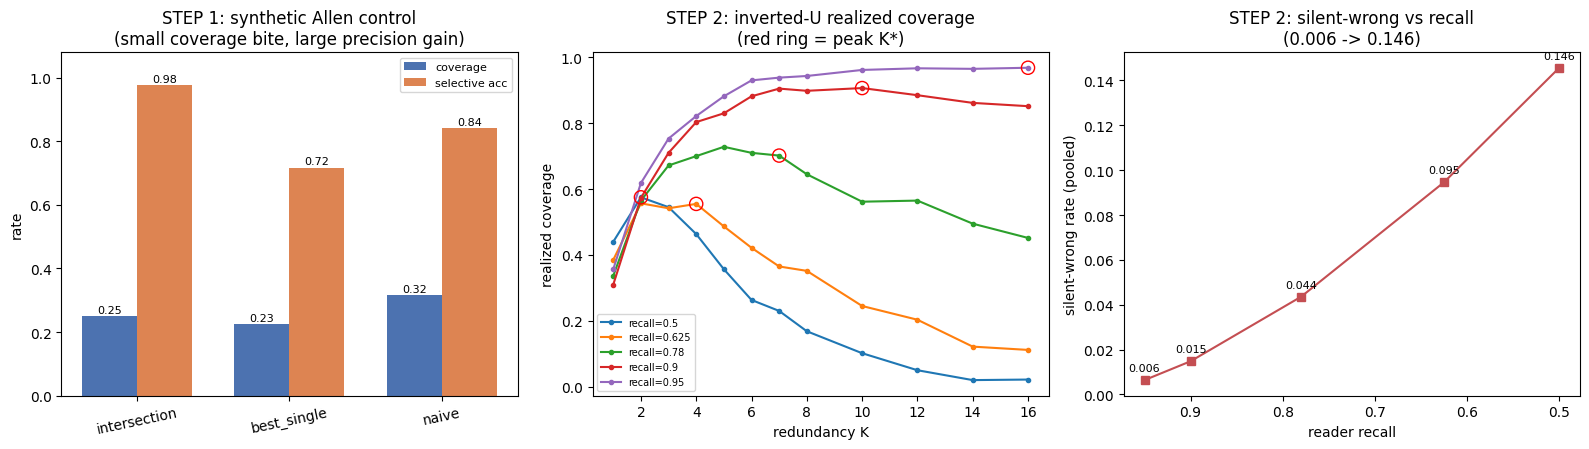

In [14]:
# ---------- printed headline summary ----------
print("="*72)
print("HEADLINE SUMMARY  (seed=%d, N_NET=%d, B_BOOT=%d, $%.2f LLM spend)" % (
    SEED, synth["n_net"], B_BOOT, metrics_agg["llm_spend_usd"]))
print("="*72)
print(f"STEP 0  reproduction mismatches : {repro['n_mismatches']}")
print(f"STEP 1  synth-Allen reproduction: {'PASS (exact)' if not synth['reproduction_failed'] else 'analytic-CI fallback (N_NET<500)'}")
cg = synth["coverage_gain_intersection_vs_best"]; sg = synth["selacc_gain_intersection_vs_best"]
print(f"        coverage gain inter-vs-best = {cg['point']:+.3f}  CI95 [{cg['ci95'][0]:+.3f}, {cg['ci95'][1]:+.3f}]  (small; CI includes 0)")
print(f"        selacc   gain inter-vs-best = {sg['point']:+.3f}  CI95 [{sg['ci95'][0]:+.3f}, {sg['ci95'][1]:+.3f}]  (large; CI excludes 0)")
print(f"STEP 2  peak K* by recall       : {inverted_u['peak_K_by_recall']}")
print(f"        max coverage gain vs K=1 : {inverted_u['max_coverage_gain_vs_K1']:.3f}")
print(f"        silent-wrong range       : [{inverted_u['silent_wrong_min']:.3f}, {inverted_u['silent_wrong_max']:.3f}]")
print("-"*72)
print("Carried headline numbers (spine / footnotes):")
for k in ("clutrr_modeA_selacc", "clutrr_modeA_vs_pot_gap", "clutrr_h2_reduction",
          "clutrr_oracle_modeA_selacc", "clutrr_atomic_recall",
          "temporal_confident_wrong_frac", "temporal_modeA_coverage"):
    print(f"  {k:32s} = {metrics_agg[k]}")
print("="*72)

# ---------- contribution-table spine (tags in columns) ----------
print("\nONE-THESIS CONTRIBUTION TABLE (spine rows):")
for i, row in enumerate(table["spine"], 1):
    print(f"  SPINE-{i}  [{row['evidence_tag']}]  status={row['status']}")
    print(f"           where: {row['where_it_holds']}")
print(f"  PENDING [{table['pending_rcc8_slot']['evidence_tag']}]  {table['pending_rcc8_slot']['status']}")

# ---------- plots ----------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (1) synthetic Allen: coverage vs selective-accuracy per method
methods = ["intersection", "best_single", "naive"]
cov = [synth["per_method"][m]["coverage"] for m in methods]
sel = [synth["per_method"][m]["selective_acc"] for m in methods]
x = np.arange(len(methods)); w = 0.36
axes[0].bar(x - w/2, cov, w, label="coverage", color="#4C72B0")
axes[0].bar(x + w/2, sel, w, label="selective acc", color="#DD8452")
for xi, (c, s) in enumerate(zip(cov, sel)):
    axes[0].text(xi - w/2, c + 0.01, f"{c:.2f}", ha="center", fontsize=8)
    axes[0].text(xi + w/2, s + 0.01, f"{s:.2f}", ha="center", fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(methods, rotation=12)
axes[0].set_ylim(0, 1.08); axes[0].set_ylabel("rate")
axes[0].set_title("STEP 1: synthetic Allen control\n(small coverage bite, large precision gain)")
axes[0].legend(fontsize=8)

# (2) inverted-U: realized coverage vs K per recall bin
for br in inverted_u["by_recall"]:
    axes[1].plot(br["Ks"], br["coverage_by_K"], marker="o", ms=3, label=f"recall={br['recall']}")
    if br["peak_K"] in br["Ks"]:
        pi = br["Ks"].index(br["peak_K"])
        axes[1].scatter([br["peak_K"]], [br["coverage_by_K"][pi]], s=90,
                        facecolors="none", edgecolors="red", zorder=5)
axes[1].set_xlabel("redundancy K"); axes[1].set_ylabel("realized coverage")
axes[1].set_title("STEP 2: inverted-U realized coverage\n(red ring = peak K*)")
axes[1].legend(fontsize=7)

# (3) silent-wrong rate vs recall
swc = inverted_u["silent_wrong_vs_recall_pooled"]
rs = [c["recall"] for c in swc]; sws = [c["silent_wrong_rate_pooled"] for c in swc]
axes[2].plot(rs, sws, marker="s", color="#C44E52")
for ri, si in zip(rs, sws):
    axes[2].text(ri, si + 0.004, f"{si:.3f}", ha="center", fontsize=8)
axes[2].set_xlabel("reader recall"); axes[2].set_ylabel("silent-wrong rate (pooled)")
axes[2].set_title("STEP 2: silent-wrong vs recall\n(0.006 -> 0.146)")
axes[2].invert_xaxis()

plt.tight_layout(); plt.show()